##### 폰트 설정

In [ ]:
!apt-get install -y fonts-nanum* > /dev/null 2>&1
!rm -rf /root/.cache/matplotlib/* > /dev/null 2>&1 # 폰트 캐시 재설정

In [ ]:
# 런타임 다시 시작 후 실행
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
#
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

#### **데이터 정리**

In [ ]:
import numpy as np
import pandas as pd

# 그래프
import seaborn as sns
import matplotlib.pyplot as plt

# ADF 정상성 여부 판단, 시계열 분해
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# ARIMA 모수추정 (하이퍼파라미터)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 잔차
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

In [ ]:
firedata = pd.read_csv('/content/산불발생여부와_일별합계.csv')

# 산불 발생 여부는 모델링에 이용하지 않아서 제거
firedata.drop(columns=['산불발생여부'], inplace=True)

# 데이터 타입 변경
firedata['date'] = pd.to_datetime(firedata['date'])
firedata['일별_합계'] = firedata['일별_합계'].astype('float32')

# 날짜순서로 정렬하고 인덱스 초기화
firedata = firedata.sort_values(by='date').reset_index(drop=True)

# 날짜를 인덱스로 설정
firedata.set_index('date', inplace=True)

# 빈도 정보 설정 : D는 일별(Daily)
#firedata = firedata.asfreq('D')  # 빈도 정보 설정: D는 일별(Daily)

# 데이터프레임을 시리즈로 변경
firedata = firedata["일별_합계"]

# 인덱스를 일 단위로 지정
firedata.index.freq = 'D'


# 데이터분할

# 2016년 1월 1일부터 2023년 12월 31일 까지를 훈련 데이터로
train_data = firedata[firedata.index < '2024-01-01']

# 2024년 1월 1일부터 2024년 12월 31일 까지를 테스트 데이터로
test_data = firedata[firedata.index >= '2024-01-01']

In [ ]:
# 2016년 - 2024년
firedata.info()
firedata.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 3288 entries, 2016-01-01 to 2024-12-31
Freq: D
Series name: 일별_합계
Non-Null Count  Dtype  
--------------  -----  
3288 non-null   float64
dtypes: float64(1)
memory usage: 51.4 KB


,일별_합계
date,
2016-01-01,0.0
2016-01-02,0.0
2016-01-03,1.0
2016-01-04,0.0
2016-01-05,1.0


In [ ]:
# 2016년 - 2023년
train_data.info()
train_data.tail()

<class 'pandas.core.series.Series'>
DatetimeIndex: 2922 entries, 2016-01-01 to 2023-12-31
Freq: D
Series name: 일별_합계
Non-Null Count  Dtype  
--------------  -----  
2922 non-null   float64
dtypes: float64(1)
memory usage: 45.7 KB


,일별_합계
date,
2023-12-27,0.0
2023-12-28,0.0
2023-12-29,0.0
2023-12-30,0.0
2023-12-31,0.0


In [ ]:
# 2024년
test_data.info()
test_data.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Freq: D
Series name: 일별_합계
Non-Null Count  Dtype  
--------------  -----  
366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


,일별_합계
date,
2024-01-01,1.0
2024-01-02,0.0
2024-01-03,0.0
2024-01-04,1.0
2024-01-05,0.0


#### **전체 데이터에 대한 ADF, 분해, ACF PACF**

**정상성 검정 ADF 테스트**

In [ ]:
# 3. ADF 테스트 (정상성 여부 판단)
result_adf_all = adfuller(firedata)

# 4. 결과 출력
print('일별_합계 (산불 발생 건수) ADF 테스트 (정상성 여부 판단)', '\n')

print("ADF 통계량:", result_adf_all[0])
print("p-value:", result_adf_all[1])
print("임계값:", result_adf_all[4])

print("사용된 시차 수:", result_adf_all[2])
print("관측값 수:", result_adf_all[3])
print("결론: 정상성 여부 =>", "정상 (stationary)" if result_adf_all[1] < 0.05 else "비정상 (non-stationary)")

일별_합계 (산불 발생 건수) ADF 테스트 (정상성 여부 판단) 

ADF 통계량: -6.275984618801954
p-value: 3.8996666473455784e-08
임계값: {'1%': -3.4323550398975238, '5%': -2.8624259071506413, '10%': -2.5672415871937777}
사용된 시차 수: 23
관측값 수: 3264
결론: 정상성 여부 => 정상 (stationary)


**시계열 데이터의 추세, 순환, 계절성 분해**

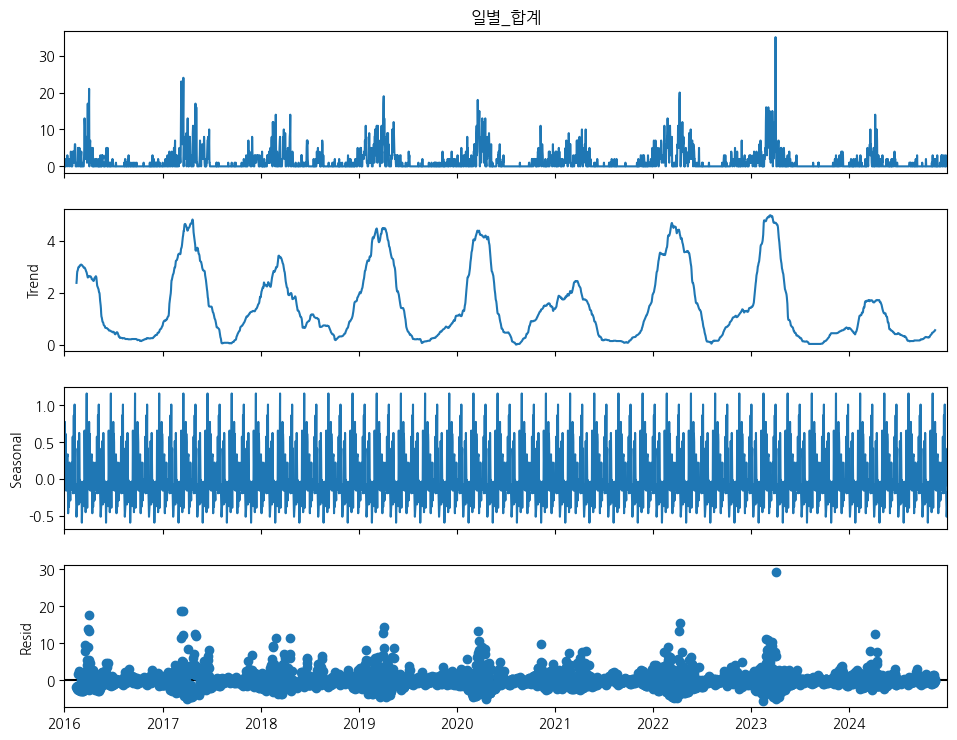

In [ ]:
ts_all = firedata
  # ts = np.log(ts2)  로그 변환 (분산 안정화)
  # ts = ts2.diff().dropna() 차분 (추세 제거)

# 시계열 데이터의 추세, 순환, 계절성 분해
# "residual" (잔차) : 원본 시계열 데이터에서 추세(trend)와 계절성(seasonality) 성분을 제거한 후 남는 부분
result_seasonal_all = sm.tsa.seasonal_decompose(ts_all, model='additive', period=90)

# 결과 시각화
fig = result_seasonal_all.plot()
fig.set_size_inches(10, 8)
plt.show()

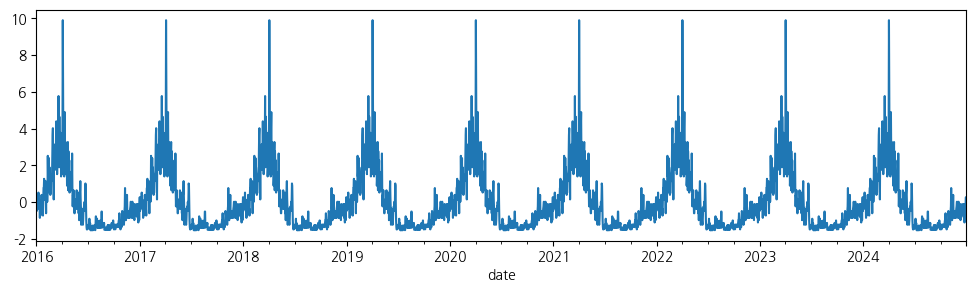

In [ ]:
result_seasonal_all = sm.tsa.seasonal_decompose(ts_all, model='additive', period=365)
seasonal_all = result_seasonal_all.seasonal

# 결과 시각화
plt.figure(figsize=(12, 3))
fig = seasonal_all.plot()
plt.show()

**ACF PACF 자기상관분석**

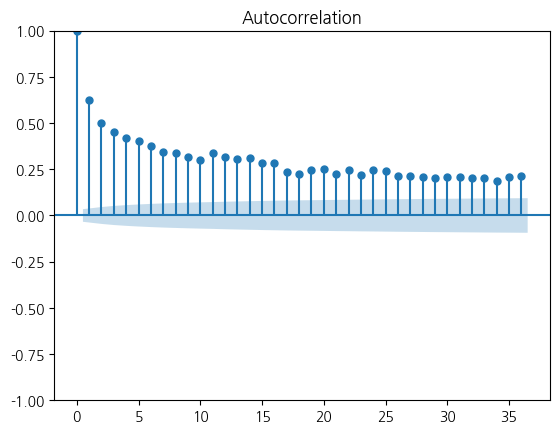

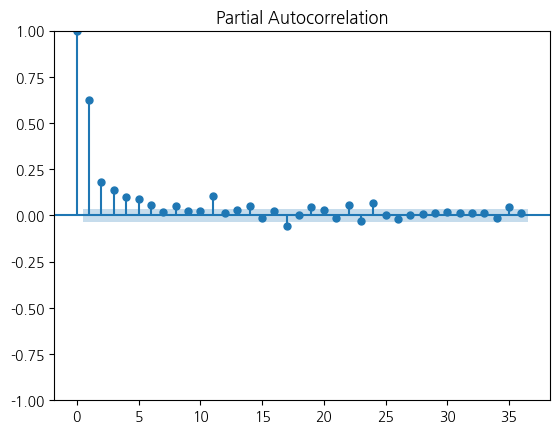

In [ ]:
plot_acf(firedata)
plot_pacf(firedata)
plt.show()

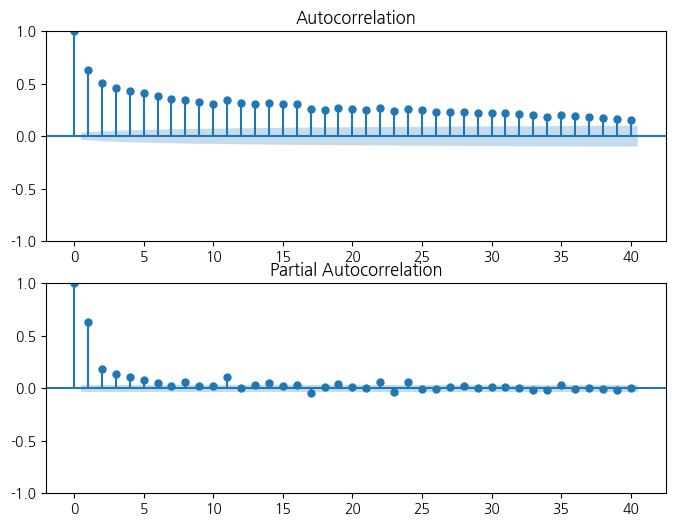

In [ ]:
y_all = firedata

# 계절성 차분: lag=90
y_seasonal_diff_all = y_all.diff(90).dropna()

# (추가로) 일반 1차 차분이 필요하면
# y_diff = y_seasonal_diff_all.diff(1).dropna()

# ACF/PACF 그리기
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(y_seasonal_diff_all, lags=40, ax=axes[0])
plot_pacf(y_seasonal_diff_all, lags=40, ax=axes[1])
plt.show()

#### **2023년까지의 데이터에 대한 ADF, 분해, ACF PACF**

**정상성 검정 ADF 테스트**

In [ ]:
# 3. ADF 테스트 (정상성 여부 판단)
result_adf_2023 = adfuller(train_data)

# 4. 결과 출력
print('일별_합계 (산불 발생 건수) ADF 테스트 (정상성 여부 판단)', '\n')

print("ADF 통계량:", result_adf_2023[0])
print("p-value:", result_adf_2023[1])
print("임계값:", result_adf_2023[4])

print("사용된 시차 수:", result_adf_2023[2])
print("관측값 수:", result_adf_2023[3])
print("결론: 정상성 여부 =>", "정상 (stationary)" if result_adf_2023[1] < 0.05 else "비정상 (non-stationary)")

일별_합계 (산불 발생 건수) ADF 테스트 (정상성 여부 판단) 

ADF 통계량: -5.955563558269051
p-value: 2.097326060772067e-07
임계값: {'1%': -3.4326084892093296, '5%': -2.8625378487837008, '10%': -2.5673011833295947}
사용된 시차 수: 23
관측값 수: 2898
결론: 정상성 여부 => 정상 (stationary)


**시계열 데이터의 추세, 순환, 계절성 분해**

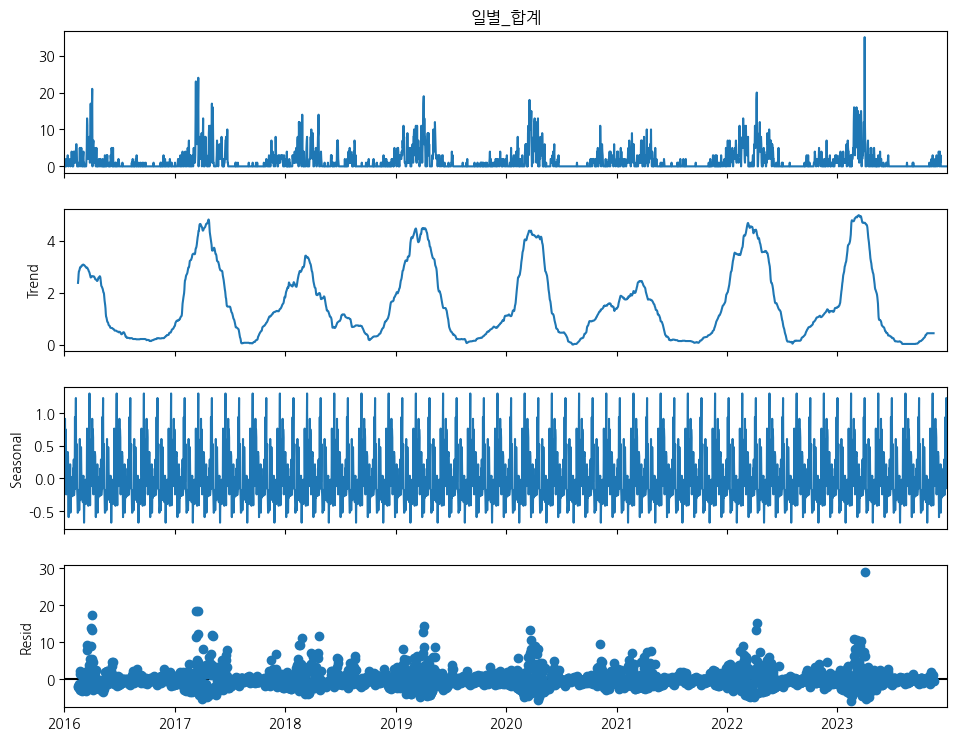

In [ ]:
ts_2023 = train_data
  # ts = np.log(ts2)  로그 변환 (분산 안정화)
  # ts = ts2.diff().dropna() 차분 (추세 제거)

# 시계열 데이터의 추세, 순환, 계절성 분해
# "residual" (잔차) : 원본 시계열 데이터에서 추세(trend)와 계절성(seasonality) 성분을 제거한 후 남는 부분
result_seasonal_2023 = sm.tsa.seasonal_decompose(ts_2023, model='additive', period=90)

# 결과 시각화
fig = result_seasonal_2023.plot()
fig.set_size_inches(10, 8)
plt.show()

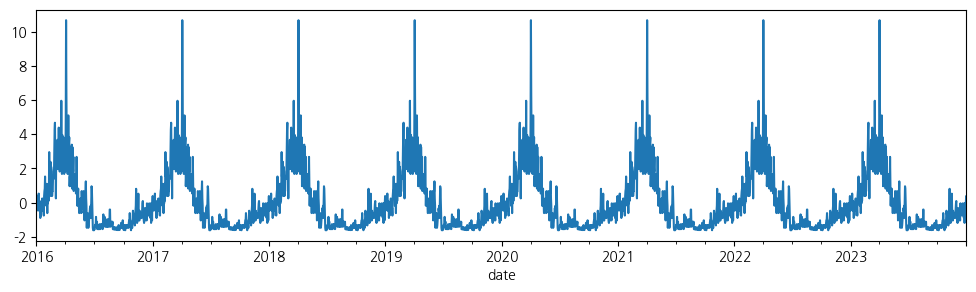

In [ ]:
result_seasonal_2023 = sm.tsa.seasonal_decompose(ts_2023, model='additive', period=365)
seasonal_2023 = result_seasonal_2023.seasonal

# 결과 시각화
plt.figure(figsize=(12, 3))
fig = seasonal_2023.plot()
plt.show()

**ACF PACF 자기상관분석**

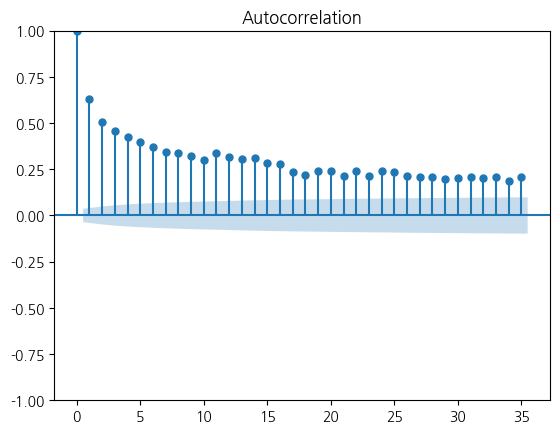

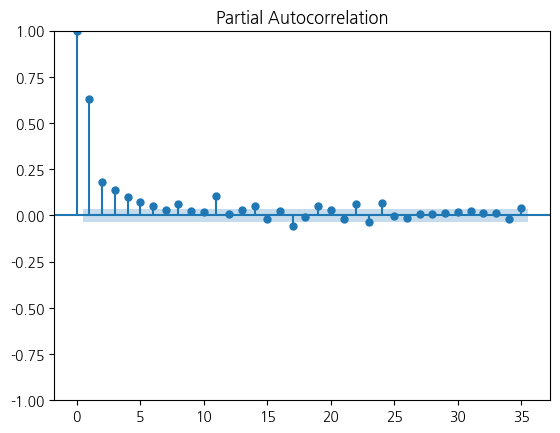

In [ ]:
plot_acf(train_data)
plot_pacf(train_data)
plt.show()

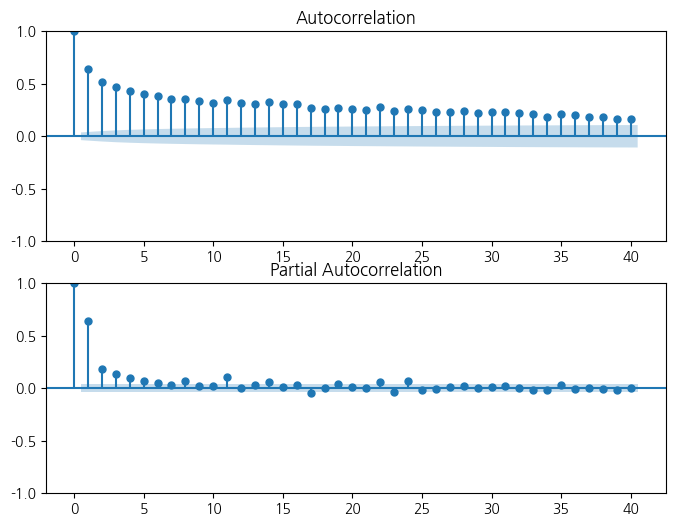

In [ ]:
y_2024 = train_data

# 계절성 차분: lag=90
y_seasonal_diff_2024 = y_2024.diff(90).dropna()

# (추가로) 일반 1차 차분이 필요하면
# y_diff = y_seasonal_diff_2024.diff(1).dropna()

# ACF/PACF 그리기
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(y_seasonal_diff_2024, lags=40, ax=axes[0])
plot_pacf(y_seasonal_diff_2024, lags=40, ax=axes[1])
plt.show()

#### **2024년 예측**

##### 모델 학습

In [ ]:
# 데이터
train_data_2024 = train_data
test_data_2024 = test_data

# 예측 대상 날짜
test_index_2024 = test_data_2024.index
n_periods_2024 = len(test_index_2024)

# SARIMA 모델 학습 및 예측
model_2024 = SARIMAX(train_data_2024, order=(2, 0, 3), seasonal_order=(1, 1, 0, 90))
model_fit_2024 = model_2024.fit()

In [ ]:
print(model_fit_2024.summary())

##### 잔차

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


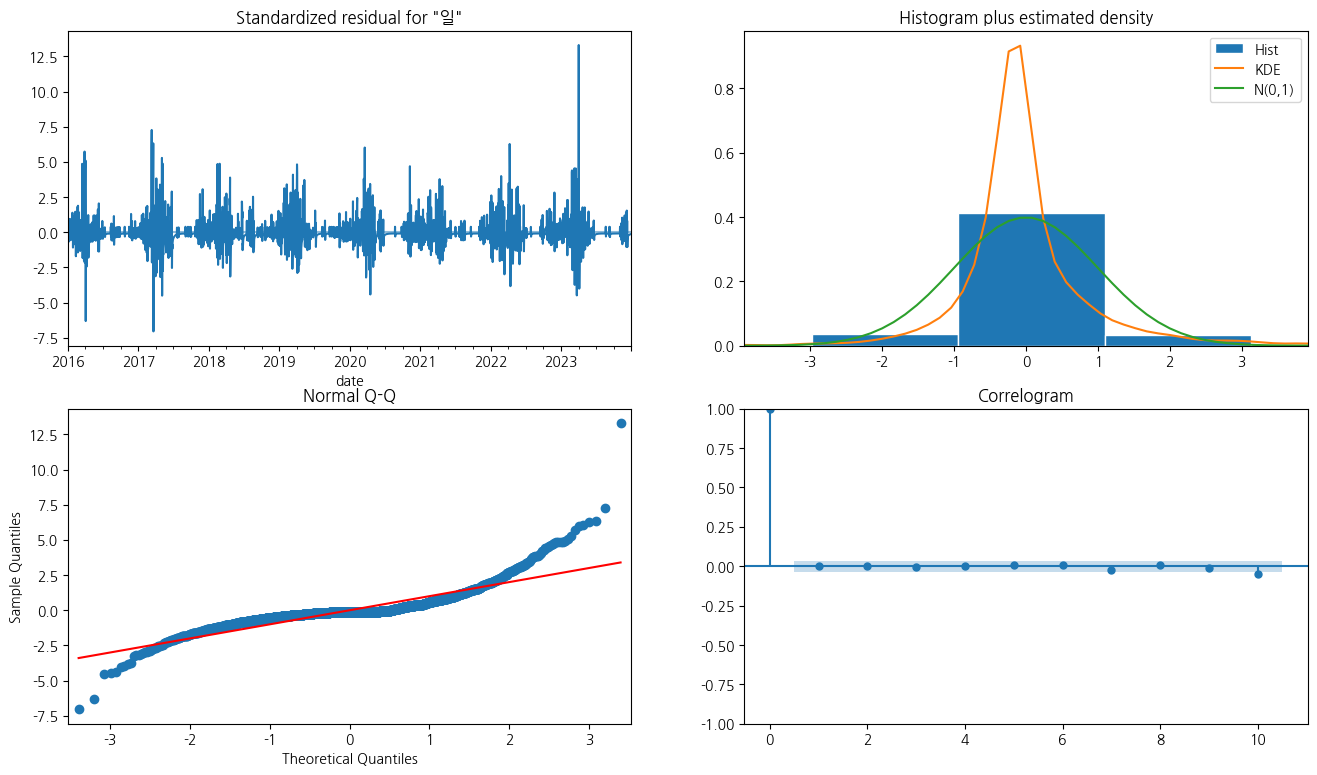

In [ ]:
# 적절한 모델인가 검증
model_fit_2024.plot_diagnostics(figsize=(16, 9))
plt.tight_layout()
plt.show()

In [ ]:
# 모델에 계절성을 반영하지 않았기 때문에 Standardized residual 그래프에 계절성이 보인다.
# Correlogram을 보면 자기상관이 없음을 알 수 있다.

In [ ]:
residuals_2024 = model_fit_2024.resid
# Ljung-Box 테스트
ljung_box_result_2024 = acorr_ljungbox(residuals_2024, lags=[7, 30, 365], return_df=True)
print(ljung_box_result_2024)

        lb_stat     lb_pvalue
7      2.415633  9.333149e-01
30    84.545779  4.299297e-07
365  376.352226  3.297873e-01


In [ ]:
# 잔차 = 오차
#
# pvalue가 0.05보다 크다면 잔차와 유의미한 자기상관이 없다고 본다.
# lags = 7    은 최근 주간의 자기상관을 나타낸다.
# lags = 30   은 최근 월간의 자기상관을 나타낸다.
# lags = 365  는 최근 연간의 자기상관을 나타낸다.
# 한달 단위는 자기상관이 존재한다.

##### 예측

In [ ]:
# 한 번에 365일 예측
forecast_result_2024 = model_fit_2024.get_forecast(steps=n_periods_2024)
fc_2024 = forecast_result_2024.predicted_mean
conf_2024 = forecast_result_2024.conf_int()

# 인덱스 부여
fc_2024.index = test_index_2024
conf_2024.index = test_index_2024

lower_2024 = conf_2024.iloc[:, 0]
upper_2024 = conf_2024.iloc[:, 1]

# 시각화
plt.figure(figsize=(15, 5))
plt.plot(train_data_2024.index, train_data_2024, alpha=0.5, label='Train 2016–2023', color='gray')
plt.plot(test_index_2024, test_data_2024, label='Actual 2024', color='blue')
plt.plot(test_index_2024, fc_2024, color='red', label='Forecast 2024')
plt.fill_between(test_index_2024, lower_2024, upper_2024, color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('2024년 산불 발생 건수 예측')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

##### 성능 평가

In [ ]:
R2 = r2_score(test_data, fc_2024)
MAE = mean_absolute_error(test_data, fc_2024)
MSE = mean_squared_error(test_data, fc_2024)
RMSE = np.sqrt(MSE)

print(f"R²Score (결정 계수) : {R2:.4f}")
print(f"MAE (평균 절대 오차) : {MAE:.4f}")
print(f"MSE (평균 제곱 오차) : {MSE:.4f}")
print(f"RMSE (제곱근 평균 제곱 오차) : {RMSE:.4f}")

R²Score (결정 계수) : 0.2256
MAE (평균 절대 오차) : 0.8321
MSE (평균 제곱 오차) : 1.8447
RMSE (제곱근 평균 제곱 오차) : 1.3582


#### **2025년 예측**

##### 모델 학습

In [ ]:
# 훈련 데이터: 2016~2024 전체
train_data_2025 = firedata

# 예측 대상 날짜 (index만 필요, 실제 값은 없음)
future_index_2025 = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
n_periods = len(future_index_2025)

# ARIMA 모델 학습 및 예측
model_2025 = SARIMAX(train_data_2025, order=(2, 0, 3), seasonal_order=(1, 1, 0, 90))
model_fit_2025  = model_2025.fit()

In [ ]:
print(model_fit_2025.summary())

                               SARIMAX Results                                
Dep. Variable:                  일별_합계   No. Observations:                 3288
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -6980.247
Date:                Wed, 14 May 2025   AIC                          13974.493
Time:                        00:25:06   BIC                          14017.179
Sample:                    01-01-2016   HQIC                         13989.776
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4411      0.462      3.121      0.002       0.536       2.346
ar.L1          1.6908      0.059     28.711      0.000       1.575       1.806
ar.L2         -0.6969      0.057    -12.251      0.0

##### 잔차

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


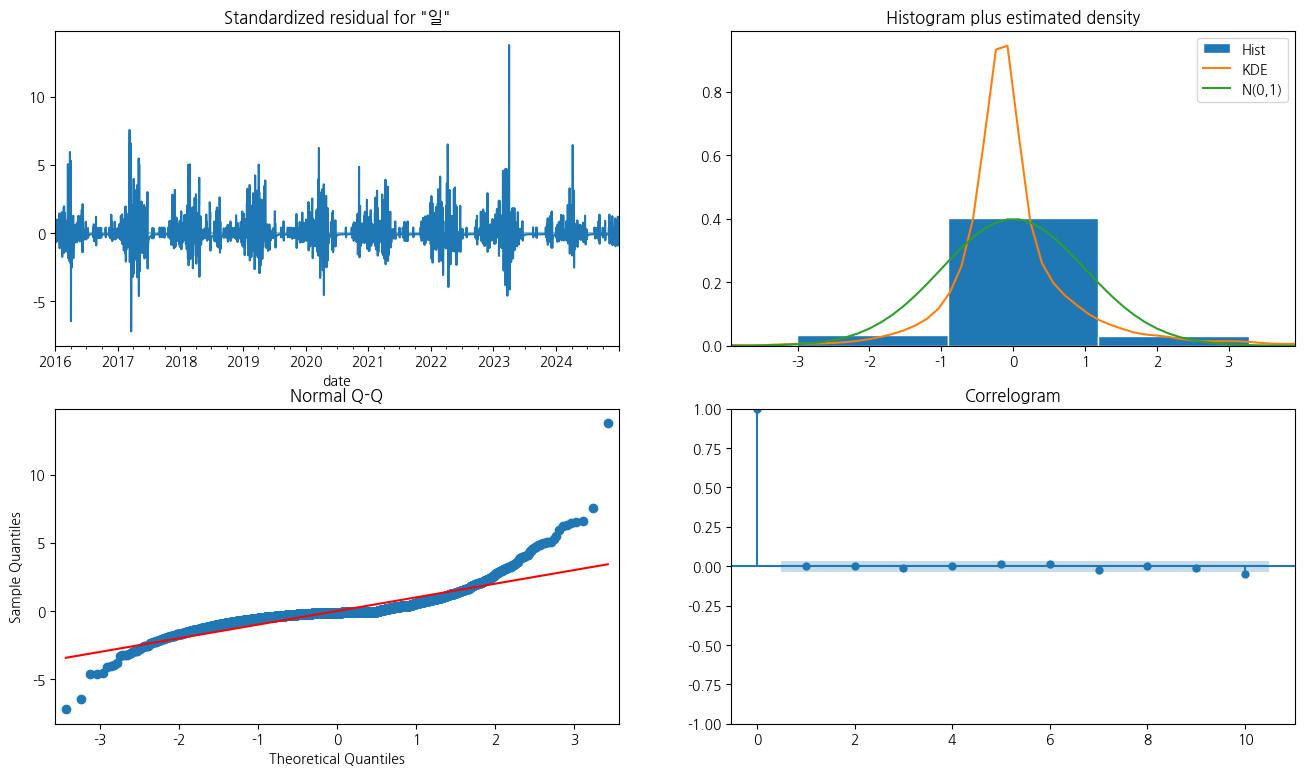

In [ ]:
# 적절한 모델인가 검증
model_fit_2025.plot_diagnostics(figsize=(16, 9))
plt.tight_layout()
plt.show()

In [ ]:
# 모델에 계절성을 반영하지 않았기 때문에 Standardized residual 그래프에 계절성이 보인다.
# Correlogram을 보면 자기상관이 없음을 알 수 있다.

In [ ]:
residuals_2025 = model_fit_2025.resid
# Ljung-Box 테스트
ljung_box_result_2025 = acorr_ljungbox(residuals_2025, lags=[7, 30, 365], return_df=True)
print(ljung_box_result_2025)

        lb_stat     lb_pvalue
7      4.221561  7.539336e-01
30    88.209983  1.223515e-07
365  380.109890  2.822062e-01


In [ ]:
# 잔차 = 오차
#
# pvalue가 0.05보다 크다면 잔차와 유의미한 자기상관이 없다고 본다.
# lags = 7    은 최근 주간의 자기상관을 나타낸다.
# lags = 30   은 최근 월간의 자기상관을 나타낸다.
# lags = 365  는 최근 연간의 자기상관을 나타낸다.
# 한달 단위는 자기상관이 존재한다.

##### 예측

In [ ]:
# 3) 한 번에 365일 예측
forecast_result_2025 = model_fit_2025.get_forecast(steps=n_periods)
fc_2025 = forecast_result_2025.predicted_mean
conf_2025 = forecast_result_2025.conf_int()

# 4) 인덱스 부여
fc_2025.index = future_index_2025
conf_2025.index = future_index_2025

lower_2025 = conf_2025.iloc[:, 0]
upper_2025 = conf_2025.iloc[:, 1]

# 6) 시각화
plt.figure(figsize=(15, 5))
#plt.plot(train_data_2025.index, train_data_2025, label='Actual 2016–2024', color='blue')
plt.plot(fc_2025.index, fc_2025, label='Forecast 2025', color='red')
plt.fill_between(fc_2025.index, lower_2025, upper_2025, color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title("2025년 산불 발생 건수 예측")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
total_2025 = fc_2025.sum()
print(f"2025년 전체 산불 발생 건수: {total_2025:.0f}건")

# 월별 건수 (월별 합계)
monthly_2025 = fc_2025.groupby(fc_2025.index.month).sum()

# 월별 출력
for month, count in monthly_2025.items():
    print(f"2025년 {month:02d}월 발생 건수: {count:.0f}건")